# Rossmann Retail Sales Forecasting & FP&A Analytics
## 06 — Final Forecast and Kaggle Submission

### Phase objective

This notebook applies the robust model selected in Phase 5 to the Kaggle test period.

The final model is:

```text
Recent 365-day Store + weekday + Promo
```

It uses only historical observations before 1 August 2015.

### Forecasting rules

- Historical averages are calculated from the latest 365 days available before the forecast horizon.
- The main segmentation is `Store + DayOfWeek + Promo`.
- The fallback hierarchy remains store-weekday, store, and global mean.
- Closed stores receive a prediction of zero.
- The 11 missing `Open` values for Store 622 use the documented Phase 2–3 decision and are treated as open.
- Submission rows are aligned exactly to `sample_submission.csv` by `Id`.

> Stop at the final review section. Check every control before uploading the submission or committing the phase.

## 1. Imports and project paths

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.11.15
pandas: 2.3.3
NumPy: 2.4.6
scikit-learn: 1.9.0


In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Confirm that data/ and notebooks/ exist."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_SUBMISSIONS_DIR = PROJECT_ROOT / "reports" / "submissions"
MODELS_DIR = PROJECT_ROOT / "models"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import build_feature_table
from src.final_forecast import (
    FINAL_BASELINE_COLUMN,
    FINAL_MODEL_NAME,
    build_submission,
    generate_final_forecast,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Final model: {FINAL_MODEL_NAME}")
print(f"Prediction column: {FINAL_BASELINE_COLUMN}")

Project root: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting
Final model: Recent 365-day Store + weekday + Promo
Prediction column: BaselineRecent365


## 2. Load the raw files

The notebook requires:

- `train.csv`
- `test.csv`
- `store.csv`
- `sample_submission.csv`

In [3]:
required_files = {
    "train": RAW_DATA_DIR / "train.csv",
    "test": RAW_DATA_DIR / "test.csv",
    "store": RAW_DATA_DIR / "store.csv",
    "sample_submission": RAW_DATA_DIR / "sample_submission.csv",
}

missing_files = [
    str(path)
    for path in required_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n- "
        + "\n- ".join(missing_files)
    )

train = pd.read_csv(
    required_files["train"],
    low_memory=False,
)
test = pd.read_csv(
    required_files["test"],
    low_memory=False,
)
store = pd.read_csv(
    required_files["store"],
    low_memory=False,
)
sample_submission = pd.read_csv(
    required_files["sample_submission"],
    low_memory=False,
)

raw_file_summary = pd.DataFrame(
    {
        "dataset": [
            "train",
            "test",
            "store",
            "sample_submission",
        ],
        "rows": [
            len(train),
            len(test),
            len(store),
            len(sample_submission),
        ],
        "columns": [
            train.shape[1],
            test.shape[1],
            store.shape[1],
            sample_submission.shape[1],
        ],
    }
)

display(raw_file_summary)

,dataset,rows,columns
0,train,1017209,9
1,test,41088,8
2,store,1115,10
3,sample_submission,41088,2


## 3. Rebuild the deterministic feature tables

The same Phase 3 feature function is applied to historical and test data.

In [4]:
train_features = build_feature_table(
    train,
    store,
    dataset_name="train",
)

test_features = build_feature_table(
    test,
    store,
    dataset_name="test",
)

feature_table_summary = pd.DataFrame(
    {
        "dataset": ["train_features", "test_features"],
        "rows": [len(train_features), len(test_features)],
        "columns": [
            train_features.shape[1],
            test_features.shape[1],
        ],
        "stores": [
            train_features["Store"].nunique(),
            test_features["Store"].nunique(),
        ],
        "minimum_date": [
            train_features["Date"].min(),
            test_features["Date"].min(),
        ],
        "maximum_date": [
            train_features["Date"].max(),
            test_features["Date"].max(),
        ],
        "missing_open_original": [
            train_features["Open"].isna().sum(),
            test_features["Open"].isna().sum(),
        ],
        "missing_open_filled": [
            train_features["OpenFilled"].isna().sum(),
            test_features["OpenFilled"].isna().sum(),
        ],
    }
)

display(feature_table_summary)

,dataset,rows,columns,stores,minimum_date,maximum_date,missing_open_original,missing_open_filled
0,train_features,1017209,47,1115,2013-01-01,2015-07-31,0,0
1,test_features,41088,46,856,2015-08-01,2015-09-17,11,0


## 4. Generate the final test forecast

The historical reference ends on 31 July 2015. The forecast begins on 1 August 2015.

No test-period sales are used.

In [22]:
scored_test = generate_final_forecast(
    train_features,
    test_features,
)

model_lookback_start = (
    scored_test["Date"].min()
    - pd.Timedelta(days=365)
)

forecast_overview = pd.DataFrame(
    {
        "metric": [
            "Final model",
            "Available historical data start",
            "Model lookback start",
            "Historical reference end",
            "Forecast start",
            "Forecast end",
            "Forecast horizon",
            "Forecast stores",
            "Forecast rows",
            "Open forecast rows",
            "Closed forecast rows",
            "Originally missing Open values",
        ],
        "value": [
            FINAL_MODEL_NAME,
            train_features["Date"].min(),
            model_lookback_start,
            train_features["Date"].max(),
            scored_test["Date"].min(),
            scored_test["Date"].max(),
            scored_test["Date"].nunique(),
            scored_test["Store"].nunique(),
            len(scored_test),
            int(scored_test["OpenFilled"].eq(1).sum()),
            int(scored_test["OpenFilled"].eq(0).sum()),
            int(scored_test["OpenMissingFlag"].sum()),
        ],
    }
)

display(forecast_overview)

,metric,value
0,Final model,Recent 365-day Store + weekday + Promo
1,Available historical data start,2013-01-01 00:00:00
2,Model lookback start,2014-08-01 00:00:00
3,Historical reference end,2015-07-31 00:00:00
4,Forecast start,2015-08-01 00:00:00
5,Forecast end,2015-09-17 00:00:00
6,Forecast horizon,48
7,Forecast stores,856
8,Forecast rows,41088
9,Open forecast rows,35104


## 5. Build the Kaggle submission

The submission is aligned to the exact `Id` order of `sample_submission.csv`.

In [23]:
submission = build_submission(
    scored_test,
    sample_submission,
)

display(submission.head())
display(submission.tail())

,Id,Sales
0,1,"4,883.6071"
1,2,"7,909.1429"
2,3,"9,753.7241"
3,4,"7,896.8621"
4,5,"7,603.7857"


,Id,Sales
41083,41084,"2,928.4118"
41084,41085,"7,965.6078"
41085,41086,"6,117.9615"
41086,41087,"22,490.9615"
41087,41088,"7,525.9615"


## 6. Submission and forecast controls

All controls must pass before the file is uploaded.

In [24]:
same_id_order = submission["Id"].equals(
    sample_submission["Id"]
)

same_id_set = set(submission["Id"]) == set(
    sample_submission["Id"]
)

closed_prediction_nonzero = int(
    (
        scored_test.loc[
            scored_test["OpenFilled"].eq(0),
            "PredictedSales",
        ]
        != 0
    ).sum()
)

missing_open_rows = scored_test.loc[
    scored_test["OpenMissingFlag"].eq(1)
].copy()

forecast_controls = pd.DataFrame(
    [
        {
            "area": "Submission",
            "control": "Same number of rows as sample submission",
            "passed": len(submission) == len(sample_submission),
            "observed_value": len(submission),
        },
        {
            "area": "Submission",
            "control": "Same Id set as sample submission",
            "passed": same_id_set,
            "observed_value": submission["Id"].nunique(),
        },
        {
            "area": "Submission",
            "control": "Same Id order as sample submission",
            "passed": same_id_order,
            "observed_value": "Compared row by row",
        },
        {
            "area": "Submission",
            "control": "No missing Sales predictions",
            "passed": submission["Sales"].isna().sum() == 0,
            "observed_value": int(submission["Sales"].isna().sum()),
        },
        {
            "area": "Submission",
            "control": "No negative Sales predictions",
            "passed": submission["Sales"].lt(0).sum() == 0,
            "observed_value": int(submission["Sales"].lt(0).sum()),
        },
        {
            "area": "Forecast",
            "control": "Closed stores receive zero",
            "passed": closed_prediction_nonzero == 0,
            "observed_value": closed_prediction_nonzero,
        },
        {
            "area": "Forecast",
            "control": "All test stores exist in historical data",
            "passed": set(test_features["Store"]).issubset(
                set(train_features["Store"])
            ),
            "observed_value": len(
                set(test_features["Store"])
                - set(train_features["Store"])
            ),
        },
        {
            "area": "Forecast",
            "control": "Test horizon contains 48 unique dates",
            "passed": scored_test["Date"].nunique() == 48,
            "observed_value": scored_test["Date"].nunique(),
        },
        {
            "area": "Forecast",
            "control": "11 missing Open values were filled",
            "passed": (
                scored_test["OpenMissingFlag"].sum() == 11
                and scored_test.loc[
                    scored_test["OpenMissingFlag"].eq(1),
                    "OpenFilled",
                ].eq(1).all()
            ),
            "observed_value": int(
                scored_test["OpenMissingFlag"].sum()
            ),
        },
        {
            "area": "Forecast",
            "control": "No missing final predictions",
            "passed": scored_test["PredictedSales"].isna().sum() == 0,
            "observed_value": int(
                scored_test["PredictedSales"].isna().sum()
            ),
        },
    ]
)

display(forecast_controls)

assert forecast_controls["passed"].all()

print("All final forecast controls passed.")

,area,control,passed,observed_value
0,Submission,Same number of rows as sample submission,True,41088
1,Submission,Same Id set as sample submission,True,41088
2,Submission,Same Id order as sample submission,True,Compared row by row
3,Submission,No missing Sales predictions,True,0
4,Submission,No negative Sales predictions,True,0
5,Forecast,Closed stores receive zero,True,0
6,Forecast,All test stores exist in historical data,True,0
7,Forecast,Test horizon contains 48 unique dates,True,48
8,Forecast,11 missing Open values were filled,True,11
9,Forecast,No missing final predictions,True,0


All final forecast controls passed.


## 7. Review the 11 imputed Open observations

These rows belong to Store 622 and were treated as open based on its historical and recent operating pattern.

In [25]:
display(
    missing_open_rows[
        [
            "Id",
            "Store",
            "Date",
            "DayOfWeek",
            "Open",
            "OpenFilled",
            "OpenMissingFlag",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "PredictedSales",
        ]
    ].sort_values("Date")
)

,Id,Store,Date,DayOfWeek,Open,OpenFilled,OpenMissingFlag,Promo,StateHoliday,SchoolHoliday,PredictedSales
10751,10752,622,2015-09-05,6,NaN,1,1,0,0,0,"2,986.8077"
9039,9040,622,2015-09-07,1,NaN,1,1,0,0,0,"4,453.0000"
8183,8184,622,2015-09-08,2,NaN,1,1,0,0,0,"4,030.5217"
7327,7328,622,2015-09-09,3,NaN,1,1,0,0,0,"3,764.8261"
6471,6472,622,2015-09-10,4,NaN,1,1,0,0,0,"3,813.4500"
5615,5616,622,2015-09-11,5,NaN,1,1,0,0,0,"4,407.0909"
4759,4760,622,2015-09-12,6,NaN,1,1,0,0,0,"2,986.8077"
3047,3048,622,2015-09-14,1,NaN,1,1,1,0,0,"6,017.4483"
2191,2192,622,2015-09-15,2,NaN,1,1,1,0,0,"5,054.3793"
1335,1336,622,2015-09-16,3,NaN,1,1,1,0,0,"4,916.8966"


## 8. Business forecast summaries

The tables below are intended for later FP&A, SQL, and Power BI work.

In [26]:
open_scored_test = scored_test.loc[
    scored_test["OpenFilled"].eq(1)
].copy()

final_forecast_summary = pd.DataFrame(
    {
        "metric": [
            "Total forecast sales",
            "Average sales per open store-day",
            "Median sales per open store-day",
            "Minimum open-store prediction",
            "Maximum open-store prediction",
            "Open store-days",
            "Closed store-days",
            "Stores forecast",
            "Forecast dates",
        ],
        "value": [
            scored_test["PredictedSales"].sum(),
            open_scored_test["PredictedSales"].mean(),
            open_scored_test["PredictedSales"].median(),
            open_scored_test["PredictedSales"].min(),
            open_scored_test["PredictedSales"].max(),
            len(open_scored_test),
            scored_test["OpenFilled"].eq(0).sum(),
            scored_test["Store"].nunique(),
            scored_test["Date"].nunique(),
        ],
    }
)

display(final_forecast_summary)

,metric,value
0,Total forecast sales,"247,034,117.4182"
1,Average sales per open store-day,"7,037.2071"
2,Median sales per open store-day,"6,565.6863"
3,Minimum open-store prediction,"1,265.7885"
4,Maximum open-store prediction,"29,063.1346"
5,Open store-days,"35,104.0000"
6,Closed store-days,"5,984.0000"
7,Stores forecast,856.0000
8,Forecast dates,48.0000


In [27]:
scored_test["OpenPromoFlag"] = (
    scored_test["OpenFilled"].eq(1)
    & scored_test["Promo"].eq(1)
).astype("int8")


daily_forecast = (
    scored_test.groupby(
        "Date",
        as_index=False,
    )
    .agg(
        forecast_sales=("PredictedSales", "sum"),
        reporting_stores=("Store", "nunique"),
        open_stores=("OpenFilled", "sum"),
        promo_store_days=("OpenPromoFlag", "sum"),
    )
)

daily_forecast["mean_sales_per_open_store"] = (
    daily_forecast["forecast_sales"]
    / daily_forecast["open_stores"].replace(0, np.nan)
)


weekday_forecast = (
    scored_test.groupby(
        "DayOfWeek",
        as_index=False,
    )
    .agg(
        rows=("Id", "size"),
        stores=("Store", "nunique"),
        forecast_sales=("PredictedSales", "sum"),
        open_store_days=("OpenFilled", "sum"),
        promo_store_days=("OpenPromoFlag", "sum"),
    )
)

weekday_forecast["mean_sales_per_open_store"] = (
    weekday_forecast["forecast_sales"]
    / weekday_forecast["open_store_days"].replace(0, np.nan)
)


promo_forecast = (
    scored_test.loc[
        scored_test["OpenFilled"].eq(1)
    ]
    .groupby(
        "Promo",
        as_index=False,
    )
    .agg(
        open_store_days=("Id", "size"),
        forecast_sales=("PredictedSales", "sum"),
        mean_sales=("PredictedSales", "mean"),
        median_sales=("PredictedSales", "median"),
    )
)


store_forecast = (
    scored_test.groupby(
        "Store",
        as_index=False,
    )
    .agg(
        forecast_sales=("PredictedSales", "sum"),
        open_days=("OpenFilled", "sum"),
        promo_days=("OpenPromoFlag", "sum"),
        mean_calendar_day_sales=("PredictedSales", "mean"),
        maximum_daily_sales=("PredictedSales", "max"),
    )
)

store_forecast["closed_days"] = (
    scored_test["Date"].nunique()
    - store_forecast["open_days"]
)

store_forecast["mean_sales_per_open_day"] = (
    store_forecast["forecast_sales"]
    / store_forecast["open_days"].replace(0, np.nan)
)

store_forecast = (
    store_forecast.sort_values(
        "forecast_sales",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(daily_forecast.head())
display(daily_forecast.tail())
display(weekday_forecast)
display(promo_forecast)
display(store_forecast.head(20))

,Date,forecast_sales,reporting_stores,open_stores,promo_store_days,mean_sales_per_open_store
0,2015-08-01,"5,351,691.2921",856,856,0,"6,251.9758"
1,2015-08-02,"206,506.9177",856,27,0,"7,648.4044"
2,2015-08-03,"8,196,576.7802",856,856,856,"9,575.4402"
3,2015-08-04,"6,999,309.3384",856,856,856,"8,176.7632"
4,2015-08-05,"6,525,116.9265",856,856,856,"7,622.8001"


,Date,forecast_sales,reporting_stores,open_stores,promo_store_days,mean_sales_per_open_store
43,2015-09-13,"206,506.9177",856,27,0,"7,648.4044"
44,2015-09-14,"8,174,858.5733",856,853,853,"9,583.6560"
45,2015-09-15,"6,979,835.0647",856,853,853,"8,182.6906"
46,2015-09-16,"6,506,549.3951",856,853,853,"7,627.8422"
47,2015-09-17,"6,490,342.3116",856,853,853,"7,608.8421"


,DayOfWeek,rows,stores,forecast_sales,open_store_days,promo_store_days,mean_sales_per_open_store
0,1,5992,856,"48,776,118.3983",5988,3421,"8,145.6444"
1,2,5992,856,"43,236,985.3703",5988,3421,"7,220.6054"
2,3,5992,856,"40,368,700.1003",5988,3421,"6,741.5999"
3,4,5992,856,"40,633,700.5035",5989,3421,"6,784.7221"
4,5,5136,856,"36,200,676.2596",5135,2568,"7,049.7909"
5,6,5992,856,"36,372,388.3626",5827,0,"6,242.0437"
6,7,5992,856,"1,445,548.4236",189,0,"7,648.4044"


,Promo,open_store_days,forecast_sales,mean_sales,median_sales
0,0,18852,"114,181,240.7554","6,056.7176","5,685.7619"
1,1,16252,"132,852,876.6627","8,174.5555","7,745.7647"


,Store,forecast_sales,open_days,promo_days,mean_calendar_day_sales,maximum_daily_sales,closed_days,mean_sales_per_open_day
0,262,"997,985.4492",48,19,"20,791.3635","29,063.1346",0,"20,791.3635"
1,1114,"877,611.8353",41,19,"18,283.5799","24,195.7586",7,"21,405.1667"
2,562,"866,713.5153",48,19,"18,056.5316","21,657.8621",0,"18,056.5316"
3,251,"799,913.9039",41,19,"16,664.8730","24,692.5172",7,"19,510.0952"
4,842,"794,340.7102",40,19,"16,548.7648","23,795.4706",8,"19,858.5178"
5,733,"736,434.8012",48,19,"15,342.3917","16,787.4333",0,"15,342.3917"
6,383,"707,005.0724",41,19,"14,729.2723","20,632.3448",7,"17,244.0262"
7,756,"706,095.0541",41,19,"14,710.3136","21,076.5862",7,"17,221.8306"
8,335,"665,326.0516",48,19,"13,860.9594","22,040.6897",0,"13,860.9594"
9,586,"653,161.1367",41,19,"13,607.5237","19,993.3929",7,"15,930.7594"


## 9. Distribution check against the final historical validation horizon

The future actual sales are unavailable. As a reasonableness check, compare forecasted open-store sales with the last 48 historical days for the same 856-store population.

This is not a performance metric. It only detects implausible shifts in scale.

In [28]:
historical_comparison_start = (
    train_features["Date"].max()
    - pd.Timedelta(days=47)
)

recent_historical = train_features.loc[
    train_features["Date"].between(
        historical_comparison_start,
        train_features["Date"].max(),
    )
    & train_features["Store"].isin(
        set(test_features["Store"])
    )
    & train_features["OpenFilled"].eq(1)
].copy()

distribution_check = pd.DataFrame(
    {
        "population": [
            "Last 48 historical days — actual open-store sales",
            "Kaggle test horizon — predicted open-store sales",
        ],
        "rows": [
            len(recent_historical),
            len(open_scored_test),
        ],
        "mean": [
            recent_historical["Sales"].mean(),
            open_scored_test["PredictedSales"].mean(),
        ],
        "median": [
            recent_historical["Sales"].median(),
            open_scored_test["PredictedSales"].median(),
        ],
        "p90": [
            recent_historical["Sales"].quantile(0.90),
            open_scored_test["PredictedSales"].quantile(0.90),
        ],
        "p99": [
            recent_historical["Sales"].quantile(0.99),
            open_scored_test["PredictedSales"].quantile(0.99),
        ],
        "maximum": [
            recent_historical["Sales"].max(),
            open_scored_test["PredictedSales"].max(),
        ],
    }
)

display(distribution_check)

,population,rows,mean,median,p90,p99,maximum
0,Last 48 historical days — actual open-store sales,35262,"7,072.7526","6,525.0000","10,715.9000","17,246.0700","41,551.0000"
1,Kaggle test horizon — predicted open-store sales,35104,"7,037.2071","6,565.6863","10,330.9643","16,773.0190","29,063.1346"


## 10. Forecast charts

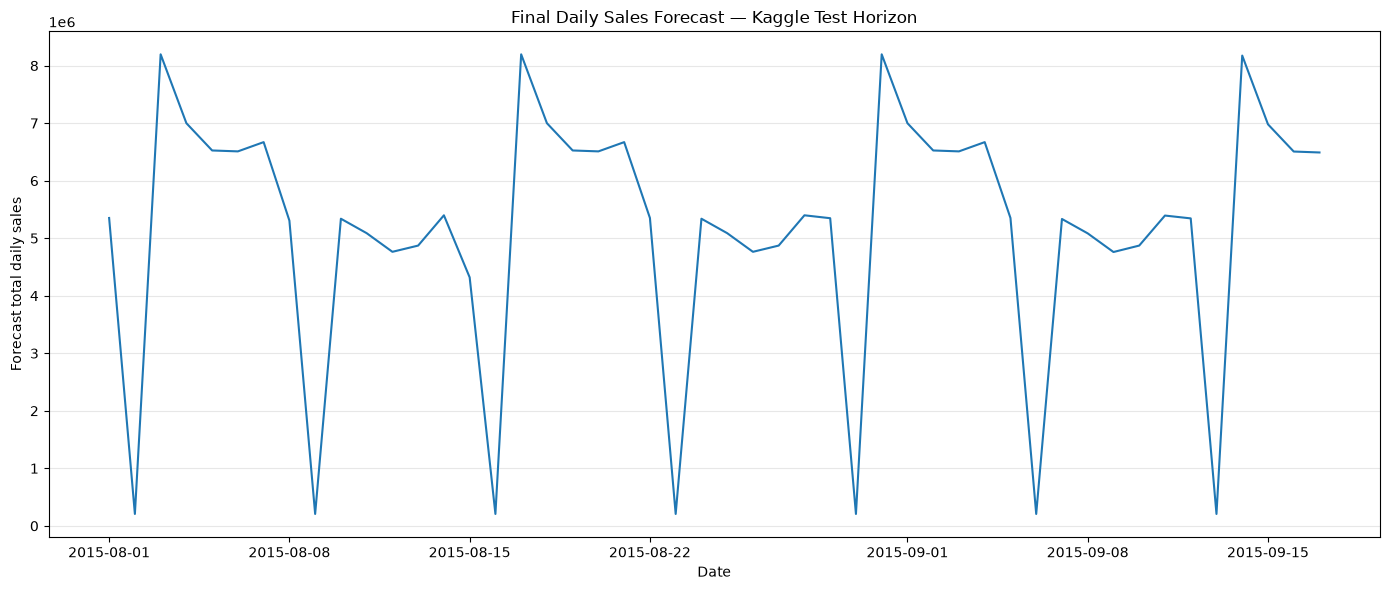

In [29]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_forecast["Date"],
    daily_forecast["forecast_sales"],
)

ax.set_title(
    "Final Daily Sales Forecast — Kaggle Test Horizon"
)
ax.set_xlabel("Date")
ax.set_ylabel("Forecast total daily sales")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

daily_forecast_figure_path = (
    REPORT_FIGURES_DIR
    / "final_daily_sales_forecast.png"
)

fig.savefig(
    daily_forecast_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

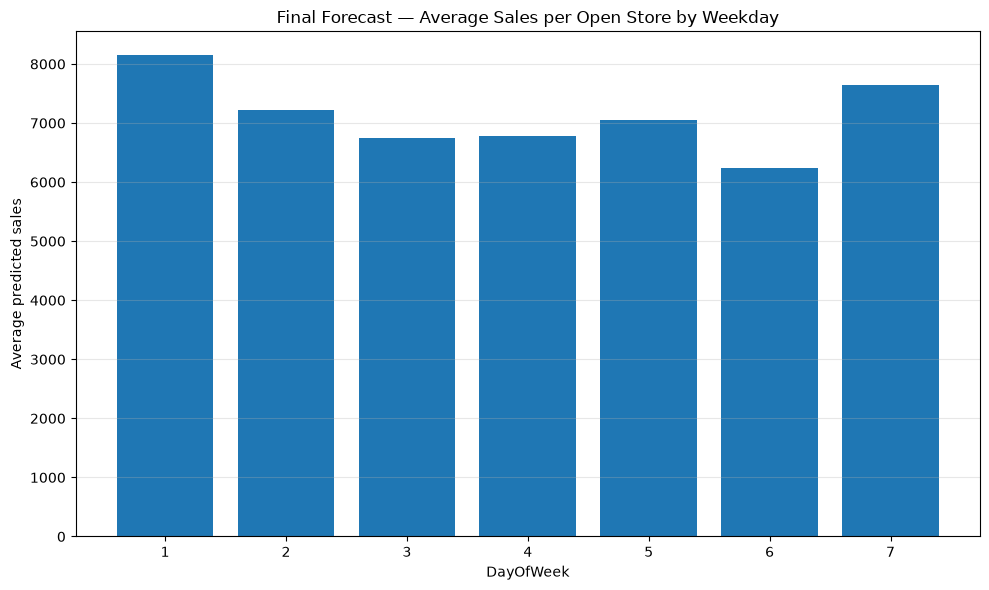

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    weekday_forecast["DayOfWeek"].astype(str),
    weekday_forecast["mean_sales_per_open_store"],
)

ax.set_title(
    "Final Forecast — Average Sales per Open Store by Weekday"
)
ax.set_xlabel("DayOfWeek")
ax.set_ylabel("Average predicted sales")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

weekday_forecast_figure_path = (
    REPORT_FIGURES_DIR
    / "final_forecast_by_weekday.png"
)

fig.savefig(
    weekday_forecast_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 11. Save the final submission and supporting outputs

The selected model is rule-based rather than a fitted estimator, so no binary model object is required.

A JSON metadata file documents the model decision and the reproducible scoring rules.

In [31]:
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

submission_path = (
    REPORT_SUBMISSIONS_DIR
    / "rossmann_submission_recent365.csv"
)
final_test_forecast_path = (
    REPORT_TABLES_DIR
    / "final_test_forecast.csv"
)
daily_forecast_path = (
    REPORT_TABLES_DIR
    / "final_daily_forecast.csv"
)
weekday_forecast_path = (
    REPORT_TABLES_DIR
    / "final_weekday_forecast.csv"
)
promo_forecast_path = (
    REPORT_TABLES_DIR
    / "final_promo_forecast.csv"
)
store_forecast_path = (
    REPORT_TABLES_DIR
    / "final_store_forecast.csv"
)
final_forecast_summary_path = (
    REPORT_TABLES_DIR
    / "final_forecast_summary.csv"
)
forecast_controls_path = (
    REPORT_TABLES_DIR
    / "final_forecast_controls.csv"
)
distribution_check_path = (
    REPORT_TABLES_DIR
    / "final_forecast_distribution_check.csv"
)
model_metadata_path = (
    MODELS_DIR
    / "final_model_metadata.json"
)

submission.to_csv(submission_path, index=False)

scored_test[
    [
        "Id",
        "Store",
        "Date",
        "DayOfWeek",
        "Open",
        "OpenFilled",
        "OpenMissingFlag",
        "Promo",
        "StateHoliday",
        "SchoolHoliday",
        "StoreType",
        "Assortment",
        "Promo2",
        "Promo2Active",
        FINAL_BASELINE_COLUMN,
        "PredictedSales",
    ]
].to_csv(
    final_test_forecast_path,
    index=False,
)

daily_forecast.to_csv(daily_forecast_path, index=False)
weekday_forecast.to_csv(weekday_forecast_path, index=False)
promo_forecast.to_csv(promo_forecast_path, index=False)
store_forecast.to_csv(store_forecast_path, index=False)
final_forecast_summary.to_csv(
    final_forecast_summary_path,
    index=False,
)
forecast_controls.to_csv(forecast_controls_path, index=False)
distribution_check.to_csv(distribution_check_path, index=False)

model_metadata = {
    "project": "Rossmann Retail Sales Forecasting & FP&A Analytics",
    "phase": 6,
    "model_name": FINAL_MODEL_NAME,
    "prediction_column": FINAL_BASELINE_COLUMN,
    "model_type": "Rule-based historical average",
    "selection_reason": (
        "Selected in Phase 5 for temporal stability: "
        "won two of three 48-day folds, had lower variability, "
        "and performed best in the final fold."
    ),
    "phase5_mean_rmspe": 0.1445,
    "phase5_rmspe_standard_deviation": 0.0088,
    "phase5_final_fold_rmspe": 0.1345,
    "history_window_days": 365,
    "segmentation": [
        "Store",
        "DayOfWeek",
        "Promo",
    ],
    "fallback_hierarchy": [
        "Store + DayOfWeek",
        "Store",
        "Global open-store mean",
    ],
    "closed_store_rule": "PredictedSales = 0 when OpenFilled = 0",
    "missing_open_rule": (
        "The 11 missing Open values for Store 622 are filled as open "
        "based on the documented historical and recent opening pattern."
    ),
    "historical_data_end": str(
        train_features["Date"].max().date()
    ),
    "forecast_start": str(scored_test["Date"].min().date()),
    "forecast_end": str(scored_test["Date"].max().date()),
    "forecast_rows": int(len(scored_test)),
    "forecast_stores": int(scored_test["Store"].nunique()),
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

with model_metadata_path.open("w", encoding="utf-8") as file:
    json.dump(
        model_metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Saved:")
print(f"- {submission_path.relative_to(PROJECT_ROOT)}")
print(f"- {final_test_forecast_path.relative_to(PROJECT_ROOT)}")
print(f"- {daily_forecast_path.relative_to(PROJECT_ROOT)}")
print(f"- {weekday_forecast_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_forecast_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_forecast_path.relative_to(PROJECT_ROOT)}")
print(f"- {final_forecast_summary_path.relative_to(PROJECT_ROOT)}")
print(f"- {forecast_controls_path.relative_to(PROJECT_ROOT)}")
print(f"- {distribution_check_path.relative_to(PROJECT_ROOT)}")
print(f"- {model_metadata_path.relative_to(PROJECT_ROOT)}")
print(f"- {daily_forecast_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {weekday_forecast_figure_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\submissions\rossmann_submission_recent365.csv
- reports\tables\final_test_forecast.csv
- reports\tables\final_daily_forecast.csv
- reports\tables\final_weekday_forecast.csv
- reports\tables\final_promo_forecast.csv
- reports\tables\final_store_forecast.csv
- reports\tables\final_forecast_summary.csv
- reports\tables\final_forecast_controls.csv
- reports\tables\final_forecast_distribution_check.csv
- models\final_model_metadata.json
- reports\figures\final_daily_sales_forecast.png
- reports\figures\final_forecast_by_weekday.png


In [32]:
# Register the external Kaggle evaluation in the model metadata

with model_metadata_path.open(
    "r",
    encoding="utf-8",
) as file:
    model_metadata = json.load(file)

model_metadata.update(
    {
        "kaggle_competition": "Rossmann Store Sales",
        "kaggle_submission_file": (
            "rossmann_submission_recent365.csv"
        ),
        "kaggle_submission_status": (
            "Complete after deadline"
        ),
        "kaggle_metric": "RMSPE",
        "kaggle_public_score": 0.12818,
        "kaggle_private_score": 0.14556,
        "kaggle_evaluated_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }
)

with model_metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Kaggle results registered in:"
)
print(
    model_metadata_path.relative_to(
        PROJECT_ROOT
    )
)

display(
    pd.DataFrame(
        {
            "metric": [
                "Submission status",
                "Public RMSPE",
                "Private RMSPE",
            ],
            "value": [
                model_metadata[
                    "kaggle_submission_status"
                ],
                model_metadata[
                    "kaggle_public_score"
                ],
                model_metadata[
                    "kaggle_private_score"
                ],
            ],
        }
    )
)

Kaggle results registered in:
models\final_model_metadata.json


,metric,value
0,Submission status,Complete after deadline
1,Public RMSPE,0.1282
2,Private RMSPE,0.1456


## Stop and review

Share the following before uploading to Kaggle or committing:

1. `feature_table_summary`
2. `forecast_overview`
3. `forecast_controls`
4. the 11 imputed `Open` rows
5. `final_forecast_summary`
6. `daily_forecast` head and tail
7. `weekday_forecast`
8. `promo_forecast`
9. `distribution_check`
10. both forecast charts
11. the first and last rows of `submission`
12. the saved-file list
13. any warning or error

### Final decisions after review

- Is the submission structurally valid?
- Are the forecast scale and daily pattern plausible?
- Should predicted sales remain as decimals or be rounded?
- Is the file ready for Kaggle upload?
- After the Kaggle score is known, should the selected model remain final or be revisited?